In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully")

Libraries imported successfully


In [ ]:
import os
import pandas as pd

try:
    from IPython.display import display
except ImportError:
    def display(x):
        print(x)

file_path = "sportsdata_set"

if not os.path.exists(file_path):
    try:
        from google.colab import files
        print(f"'{file_path}' not found — please upload it now.")
        uploaded = files.upload()
        file_path = list(uploaded.keys())[0]
    except ImportError:
        raise FileNotFoundError(
            f"Could not find '{file_path}'. Place it in the same folder as "
            "this notebook, or update file_path to its full location."
        )

df = pd.read_csv(file_path)

print("Dataset loaded successfully")
display(df.head())

'sportsdata_set' not found — please upload it now.


Saving sportsdata_set to sportsdata_set
Dataset loaded successfully


,ID,Name,Age,Overall,Potential,Preferred Foot,Position,Finishing
0,158023,L. Messi,31,94,94,Left,RF,95
1,20801,Cristiano Ronaldo,33,94,94,Right,ST,94
2,190871,Neymar Jr,26,92,93,Right,LW,87
3,193080,De Gea,27,91,93,Right,GK,13
4,192985,K. De Bruyne,27,91,92,Right,RCM,82


In [ ]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])
print("Dataset shape:", df.shape)

Number of rows: 499
Number of columns: 8
Dataset shape: (499, 8)


In [ ]:
print("Column names:")
print(df.columns.tolist())

Column names:
['ID', 'Name', 'Age', 'Overall', 'Potential', 'Preferred Foot', 'Position', 'Finishing']


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 499 entries, 0 to 498
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   ID              499 non-null    int64 
 1   Name            499 non-null    object
 2   Age             499 non-null    int64 
 3   Overall         499 non-null    int64 
 4   Potential       499 non-null    int64 
 5   Preferred Foot  499 non-null    object
 6   Position        499 non-null    object
 7   Finishing       499 non-null    int64 
dtypes: int64(5), object(3)
memory usage: 31.3+ KB


In [ ]:
df.describe()

,ID,Age,Overall,Potential,Finishing
count,499.000000,499.000000,499.000000,499.000000,499.000000
mean,192223.695391,27.192385,82.905812,84.831663,59.615230
std,33005.328078,3.629290,2.688878,3.220124,23.408719
min,41.000000,18.000000,80.000000,80.000000,8.000000
25%,183536.000000,25.000000,81.000000,82.000000,45.000000
50%,198219.000000,27.000000,82.000000,84.000000,68.000000
75%,208819.000000,30.000000,84.000000,87.000000,78.000000
max,239207.000000,40.000000,94.000000,95.000000,95.000000


In [ ]:
print("Missing values in each column:")

print(df.isnull().sum())

Missing values in each column:
ID                0
Name              0
Age               0
Overall           0
Potential         0
Preferred Foot    0
Position          0
Finishing         0
dtype: int64


In [ ]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

print(missing_percentage)

ID                0.0
Name              0.0
Age               0.0
Overall           0.0
Potential         0.0
Preferred Foot    0.0
Position          0.0
Finishing         0.0
dtype: float64


In [ ]:
missing_report = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": (
        df.isnull().sum() / len(df) * 100
    ).round(2)
})

display(missing_report)

,Missing Count,Missing Percentage
ID,0,0.0
Name,0,0.0
Age,0,0.0
Overall,0,0.0
Potential,0,0.0
Preferred Foot,0,0.0
Position,0,0.0
Finishing,0,0.0


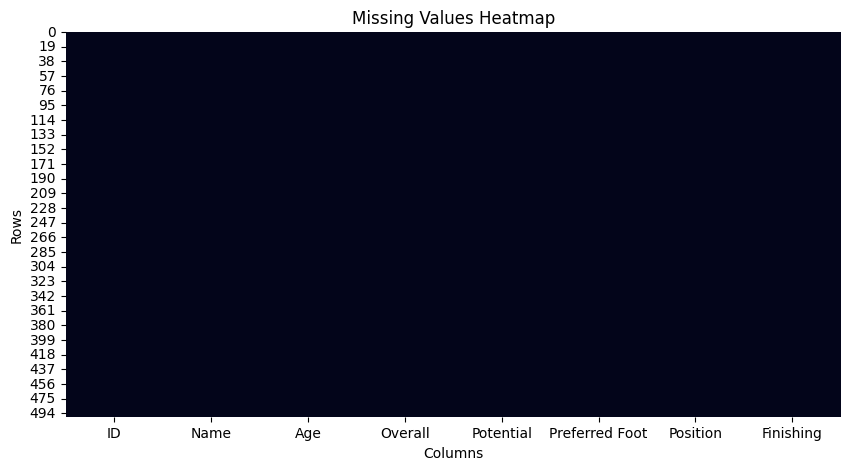

In [ ]:
plt.figure(figsize=(10, 5))

sns.heatmap(df.isnull(), cbar=False)

plt.title("Missing Values Heatmap")
plt.xlabel("Columns")
plt.ylabel("Rows")

plt.show()

In [ ]:
numeric_columns = df.select_dtypes(
    include=np.number
).columns

categorical_columns = df.select_dtypes(
    exclude=np.number
).columns

# Fill numeric missing values with median
for col in numeric_columns:
    df[col] = df[col].fillna(df[col].median())

# Fill categorical missing values with mode
for col in categorical_columns:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])

print("Missing values handled")
print(df.isnull().sum())

Missing values handled
ID                0
Name              0
Age               0
Overall           0
Potential         0
Preferred Foot    0
Position          0
Finishing         0
dtype: int64


In [ ]:
print("Total duplicate rows:", df.duplicated().sum())

Total duplicate rows: 0


In [ ]:
duplicates = df[df.duplicated(keep=False)]

display(duplicates)

,ID,Name,Age,Overall,Potential,Preferred Foot,Position,Finishing


In [ ]:
print("Rows before:", len(df))

df = df.drop_duplicates()

print("Rows after:", len(df))

Rows before: 499
Rows after: 499


In [ ]:
print("Remaining duplicates:", df.duplicated().sum())

Remaining duplicates: 0


In [ ]:
print(df["Position"].unique())

['RF' 'ST' 'LW' 'GK' 'RCM' 'LF' 'RS' 'RCB' 'LCM' 'CB' 'LDM' 'CAM' 'CDM'
 'LS' 'LCB' 'RM' 'LAM' 'LM' 'LB' 'RDM' 'RW' 'CM' 'RB' 'RAM' 'CF' 'RWB'
 'LWB']


In [ ]:
print(df["Position"].value_counts())

Position
GK     57
ST     38
LM     33
CAM    32
RM     30
CB     29
RCB    29
LCB    28
CM     26
LB     24
RB     23
LCM    20
RCM    19
RW     19
CDM    19
LS     16
LDM    11
LW     10
RS     10
RDM     8
CF      5
LF      4
RF      2
LAM     2
RAM     2
RWB     2
LWB     1
Name: count, dtype: int64


In [ ]:
numeric_columns = ["Age", "Overall", "Potential", "Finishing"]

for col in numeric_columns:
    print(f"\n{col} zero count:", (df[col] == 0).sum())


Age zero count: 0

Overall zero count: 0

Potential zero count: 0

Finishing zero count: 0


In [ ]:
for col in ["Age", "Overall", "Potential", "Finishing"]:
    print(f"Negative {col}:", (df[col] < 0).sum())

Negative Age: 0
Negative Overall: 0
Negative Potential: 0
Negative Finishing: 0


In [ ]:
print("Preferred Foot values:")
print(df["Preferred Foot"].value_counts())

Preferred Foot values:
Preferred Foot
Right    368
Left     131
Name: count, dtype: int64


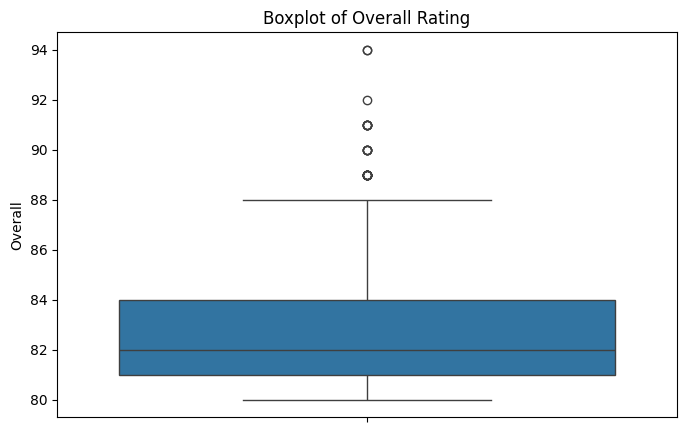

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(y=df["Overall"])

plt.title("Boxplot of Overall Rating")

plt.show()

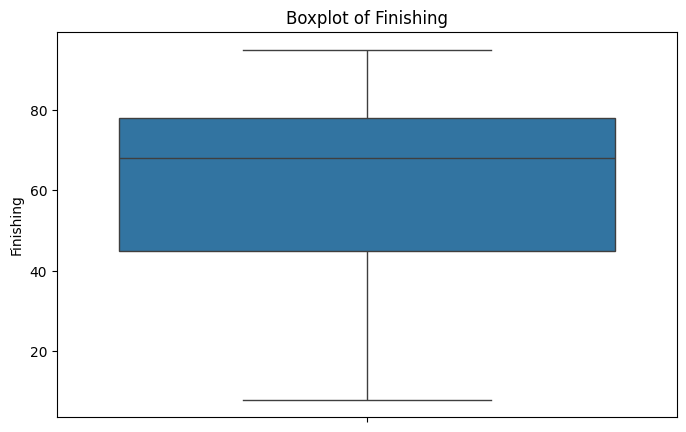

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(y=df["Finishing"])

plt.title("Boxplot of Finishing")

plt.show()

In [ ]:
def detect_outliers(column):

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]

    print("Column:", column)
    print("Q1:", Q1)
    print("Q3:", Q3)
    print("IQR:", IQR)
    print("Outliers:", len(outliers))

    return outliers

overall_outliers = detect_outliers("Overall")
finishing_outliers = detect_outliers("Finishing")

Column: Overall
Q1: 81.0
Q3: 84.0
IQR: 3.0
Outliers: 25
Column: Finishing
Q1: 45.0
Q3: 78.0
IQR: 33.0
Outliers: 0


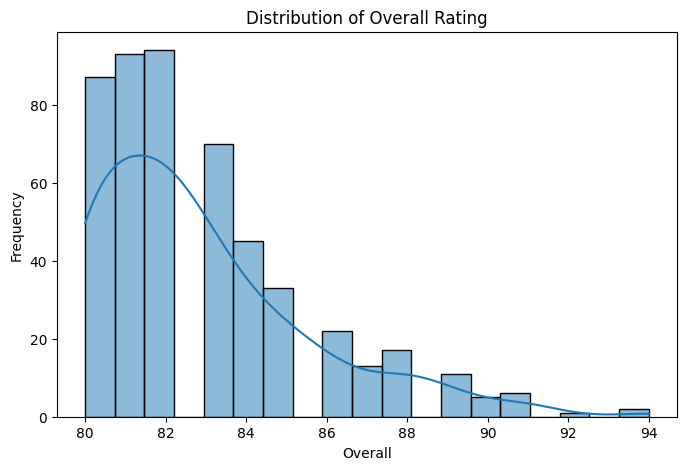

In [ ]:
plt.figure(figsize=(8, 5))

sns.histplot(df["Overall"], kde=True)

plt.title("Distribution of Overall Rating")
plt.xlabel("Overall")
plt.ylabel("Frequency")

plt.show()

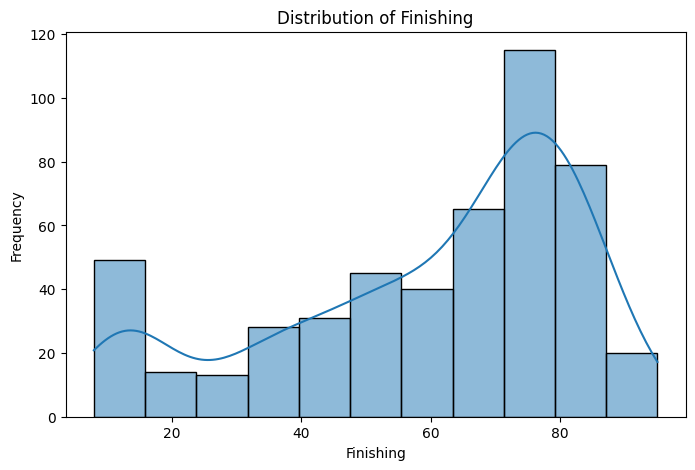

In [ ]:
plt.figure(figsize=(8, 5))

sns.histplot(df["Finishing"], kde=True)

plt.title("Distribution of Finishing")
plt.xlabel("Finishing")
plt.ylabel("Frequency")

plt.show()

In [ ]:
print("Overall skewness:", df["Overall"].skew())

print("Finishing skewness:", df["Finishing"].skew())

Overall skewness: 1.2698532697623368
Finishing skewness: -0.7932103458758062


In [ ]:
position_counts = df["Position"].value_counts()

display(position_counts)

,count
Position,
GK,57
ST,38
LM,33
CAM,32
RM,30
CB,29
RCB,29
LCB,28
CM,26


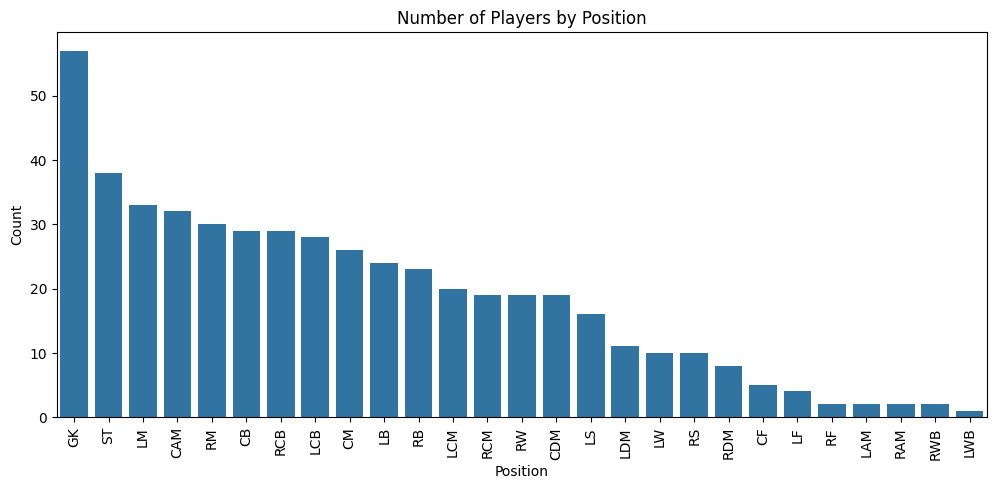

In [ ]:
plt.figure(figsize=(12, 5))

sns.countplot(
    data=df,
    x="Position",
    order=df["Position"].value_counts().index
)

plt.title("Number of Players by Position")
plt.xlabel("Position")
plt.ylabel("Count")
plt.xticks(rotation=90)

plt.show()

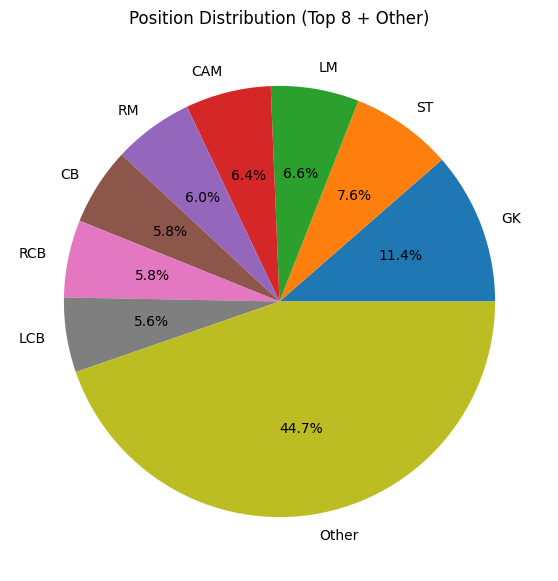

In [ ]:
# Group the smaller positions into "Other" so the pie chart stays readable
top_positions = df["Position"].value_counts().head(8)
other_count = df["Position"].value_counts().iloc[8:].sum()

pie_data = top_positions.copy()
pie_data["Other"] = other_count

pie_data.plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(7, 7)
)

plt.title("Position Distribution (Top 8 + Other)")
plt.ylabel("")

plt.show()

In [ ]:
print("Average Overall rating:", df["Overall"].mean())

print("Median Overall rating:", df["Overall"].median())

print("Maximum Overall rating:", df["Overall"].max())

print("Minimum Overall rating:", df["Overall"].min())

Average Overall rating: 82.90581162324649
Median Overall rating: 82.0
Maximum Overall rating: 94
Minimum Overall rating: 80


In [ ]:
overall_by_position = df.groupby(
    "Position"
)["Overall"].agg([
    "mean",
    "min",
    "max",
    "count"
])

display(overall_by_position.sort_values("mean", ascending=False))

,mean,min,max,count
Position,,,,
RF,90.500000,87,94,2
LF,87.000000,82,91,4
LW,85.000000,81,92,10
LAM,84.500000,81,88,2
ST,83.605263,80,94,38
RAM,83.500000,83,84,2
RCM,83.473684,80,91,19
LCM,83.450000,80,90,20
GK,83.350877,80,91,57


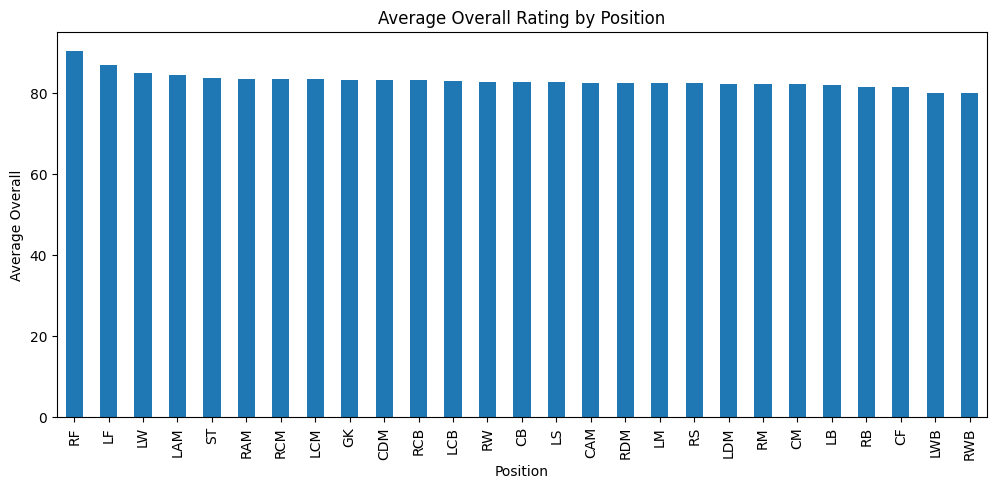

In [ ]:
df.groupby("Position")["Overall"].mean().sort_values(ascending=False).plot(
    kind="bar",
    figsize=(12, 5)
)

plt.title("Average Overall Rating by Position")
plt.xlabel("Position")
plt.ylabel("Average Overall")

plt.xticks(rotation=90)

plt.show()

In [ ]:
df["High Potential"] = (
    df["Potential"] > df["Overall"]
).astype(int)

display(df[["Name", "Overall", "Potential", "High Potential"]].head())

,Name,Overall,Potential,High Potential
0,L. Messi,94,94,0
1,Cristiano Ronaldo,94,94,0
2,Neymar Jr,92,93,1
3,De Gea,91,93,1
4,K. De Bruyne,91,92,1


In [ ]:
high_potential_count = (df["High Potential"] == 1).sum()

at_ceiling_count = (df["High Potential"] == 0).sum()

total_count = len(df)

print("High Potential:", high_potential_count)

print("At Ceiling:", at_ceiling_count)

print("Total:", total_count)

High Potential: 263
At Ceiling: 236
Total: 499


In [ ]:
high_potential_percentage = (
    high_potential_count / total_count
) * 100

print(f"High Potential Percentage: {high_potential_percentage:.2f}%")

High Potential Percentage: 52.71%


In [ ]:
at_ceiling_percentage = (
    at_ceiling_count / total_count
) * 100

print(f"At Ceiling Percentage: {at_ceiling_percentage:.2f}%")

At Ceiling Percentage: 47.29%


In [ ]:
import pandas as pd

# Example data
total_count = 100
high_potential_count = 60
at_ceiling_count = 40

# Calculate percentages
high_potential_percentage = (high_potential_count / total_count) * 100
at_ceiling_percentage = (at_ceiling_count / total_count) * 100

# Create DataFrame
potential_analysis = pd.DataFrame({
    "Category": [
        "High Potential",
        "At Ceiling",
        "Total"
    ],

    "Count": [
        high_potential_count,
        at_ceiling_count,
        total_count
    ],

    "Percentage": [
        high_potential_percentage,
        at_ceiling_percentage,
        100.00
    ]
})

# Round percentages to 2 decimal places
potential_analysis["Percentage"] = (
    potential_analysis["Percentage"].round(2)
)

# Display the result
display(potential_analysis)

,Category,Count,Percentage
0,High Potential,60,60.0
1,At Ceiling,40,40.0
2,Total,100,100.0


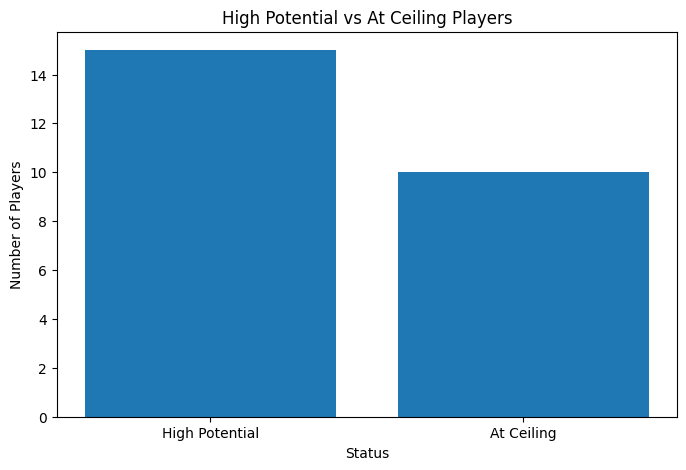

In [ ]:
import matplotlib.pyplot as plt

# Example player counts
high_potential_count = 15
at_ceiling_count = 10

# Create bar chart
plt.figure(figsize=(8, 5))

plt.bar(
    ["High Potential", "At Ceiling"],
    [high_potential_count, at_ceiling_count]
)

plt.title("High Potential vs At Ceiling Players")
plt.xlabel("Status")
plt.ylabel("Number of Players")

plt.show()

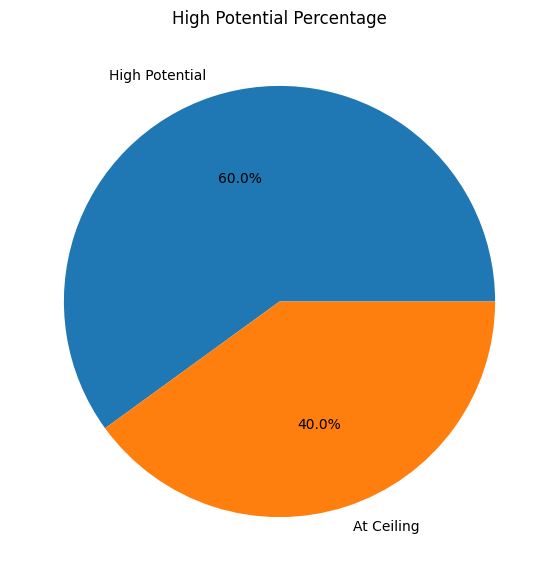

In [ ]:
plt.figure(figsize=(7, 7))

plt.pie(
    [high_potential_count, at_ceiling_count],
    labels=["High Potential", "At Ceiling"],
    autopct="%1.1f%%"
)

plt.title("High Potential Percentage")

plt.show()

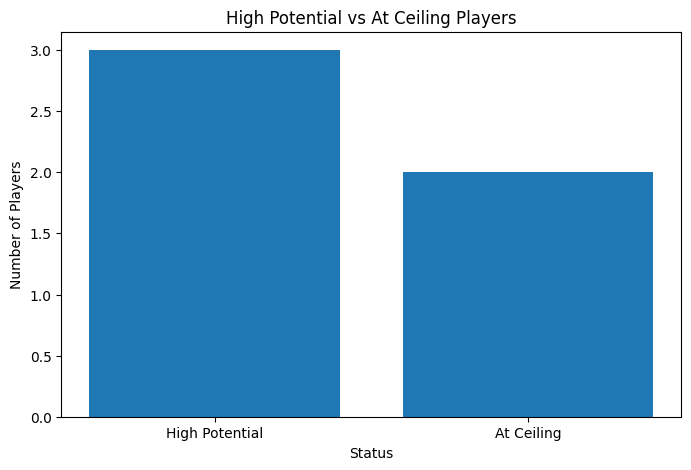

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Define the DataFrame
df = pd.DataFrame({
    "Player": ["Player 1", "Player 2", "Player 3", "Player 4", "Player 5"],
    "Status": [
        "High Potential",
        "At Ceiling",
        "High Potential",
        "High Potential",
        "At Ceiling"
    ]
})

# Count players in each status
high_potential_count = (df["Status"] == "High Potential").sum()
at_ceiling_count = (df["Status"] == "At Ceiling").sum()

# Create the bar chart
plt.figure(figsize=(8, 5))

plt.bar(
    ["High Potential", "At Ceiling"],
    [high_potential_count, at_ceiling_count]
)

plt.title("High Potential vs At Ceiling Players")
plt.xlabel("Status")
plt.ylabel("Number of Players")

plt.show()

In [ ]:
import pandas as pd

# Define the DataFrame
df = pd.DataFrame({
    "Player": ["Player 1", "Player 2", "Player 3", "Player 4", "Player 5"],
    "Position": ["Forward", "Defender", "Forward", "Goalkeeper", "Defender"],
    "Status": [
        "High Potential",
        "At Ceiling",
        "High Potential",
        "At Ceiling",
        "High Potential"
    ]
})

# Create a True/False column for High Potential
df["High Potential"] = df["Status"] == "High Potential"

# Calculate percentage of High Potential players by Position
potential_rate = (
    df.groupby("Position")["High Potential"].mean() * 100
)

# Round to 2 decimal places
potential_rate = potential_rate.round(2)

# Display from highest to lowest
display(potential_rate.sort_values(ascending=False))

,High Potential
Position,
Forward,100.0
Defender,50.0
Goalkeeper,0.0


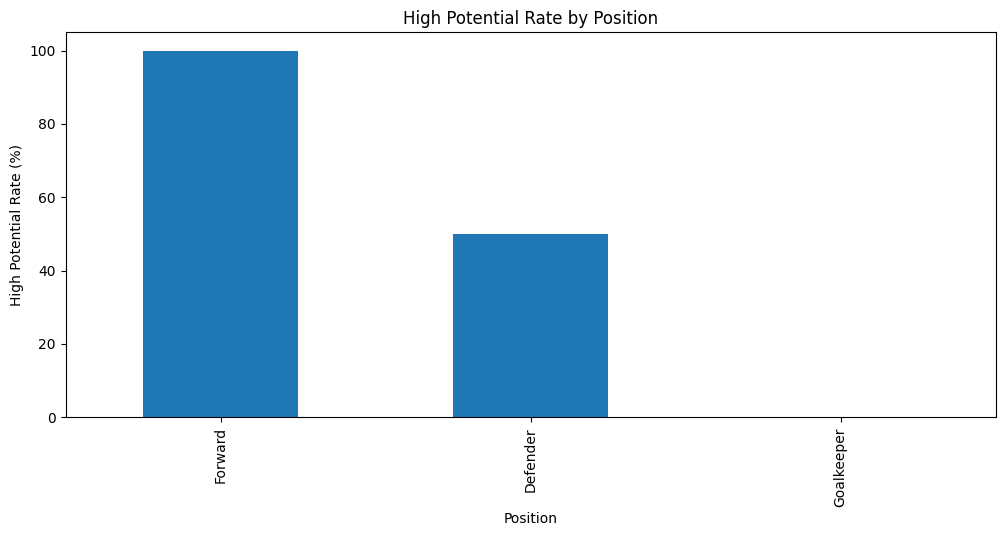

In [ ]:
plt.figure(figsize=(12, 5))

potential_rate.sort_values(ascending=False).plot(kind="bar")

plt.title("High Potential Rate by Position")
plt.xlabel("Position")
plt.ylabel("High Potential Rate (%)")

plt.xticks(rotation=90)

plt.show()

In [ ]:
import pandas as pd

# Define the DataFrame
df = pd.DataFrame({
    "Player": ["Player 1", "Player 2", "Player 3", "Player 4", "Player 5"],
    "Position": ["Forward", "Midfielder", "Forward", "Defender", "Forward"],
    "Finishing": [85, 78, 92, 65, 88]
})

# Convert Finishing to numeric
df["Finishing"] = pd.to_numeric(df["Finishing"], errors="coerce")

# Calculate statistics
print("Average Finishing:", df["Finishing"].mean())
print("Median Finishing:", df["Finishing"].median())
print("Maximum Finishing:", df["Finishing"].max())
print("Minimum Finishing:", df["Finishing"].min())

Average Finishing: 81.6
Median Finishing: 85.0
Maximum Finishing: 92
Minimum Finishing: 65


In [ ]:
import pandas as pd

# Define the DataFrame
df = pd.DataFrame({
    "Player": ["Player 1", "Player 2", "Player 3", "Player 4", "Player 5"],
    "Position": [
        "Forward",
        "Midfielder",
        "Forward",
        "Defender",
        "Midfielder"
    ],
    "Finishing": [85, 78, 92, 65, 88]
})

# Make sure Finishing contains numeric values
df["Finishing"] = pd.to_numeric(df["Finishing"], errors="coerce")

# Calculate Finishing statistics by Position
finishing_by_position = df.groupby(
    "Position"
)["Finishing"].agg([
    "mean",
    "min",
    "max"
])

# Sort by average Finishing
display(
    finishing_by_position.sort_values(
        "mean",
        ascending=False
    )
)

,mean,min,max
Position,,,
Forward,88.5,85,92
Midfielder,83.0,78,88
Defender,65.0,65,65


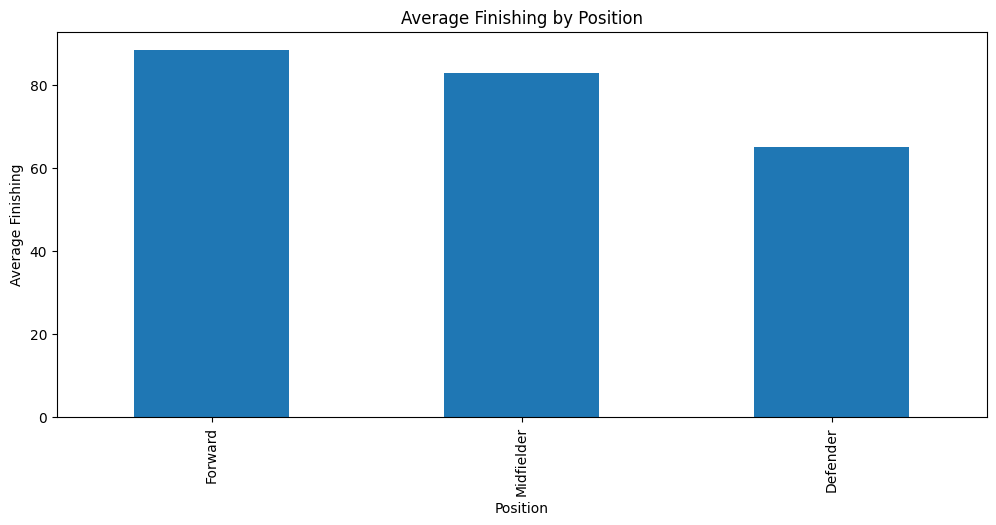

In [ ]:
df.groupby("Position")["Finishing"].mean().sort_values(ascending=False).plot(
    kind="bar",
    figsize=(12, 5)
)

plt.title("Average Finishing by Position")
plt.xlabel("Position")
plt.ylabel("Average Finishing")

plt.xticks(rotation=90)

plt.show()

In [ ]:
import pandas as pd

# Define the DataFrame
df = pd.DataFrame({
    "Player": ["Player 1", "Player 2", "Player 3", "Player 4", "Player 5"],
    "Age": [20, 24, 28, 22, 26],
    "Overall": [75, 82, 88, 70, 85],
    "Potential": [85, 84, 88, 80, 86],
    "Finishing": [78, 85, 90, 65, 88]
})

# Select the required columns
columns = ["Age", "Overall", "Potential", "Finishing"]

# Convert columns to numeric
df[columns] = df[columns].apply(pd.to_numeric, errors="coerce")

# Calculate correlation
correlation = df[columns].corr()

# Display correlation matrix
display(correlation)

,Age,Overall,Potential,Finishing
Age,1.000000,0.878124,0.639602,0.733302
Overall,0.878124,1.000000,0.879005,0.969069
Potential,0.639602,0.879005,1.000000,0.918084
Finishing,0.733302,0.969069,0.918084,1.000000


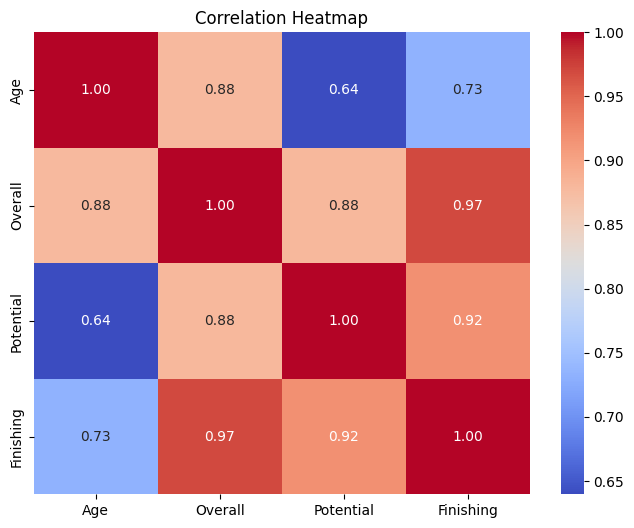

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

In [ ]:
print("Final dataset shape:", df.shape)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nData types:")
print(df.dtypes)

Final dataset shape: (5, 4)

Missing values:
Age          0
Overall      0
Potential    0
Finishing    0
dtype: int64

Duplicate rows: 0

Data types:
Age          int64
Overall      int64
Potential    int64
Finishing    int64
dtype: object


In [ ]:
display(df.head(10))

,Age,Overall,Potential,Finishing
0,20,75,85,78
1,24,82,84,85
2,28,88,88,90
3,22,70,80,65
4,26,85,86,88


In [ ]:
output_file = "sportsdata_cleaned_final.csv"

df.to_csv(
    output_file,
    index=False
)

print("Cleaned dataset saved successfully")

Cleaned dataset saved successfully
